# 05. 튜닝 — 산식을 제대로 최적화하기

## 이 노트북의 목적 (Phase 4)

Phase 3에서 LightGBM(L1 손실)을 골라 2024 홀드아웃 `total_score` **0.6074**를 얻었다.
그 뒤 사전조사에서 **훨씬 큰 개선 여지가 모델이 아니라 "산식을 읽는 법"에 있다**는 것을 발견했다.
이 노트북은 그 발견을 정식 실험으로 검증하고 하이퍼파라미터까지 튜닝한다.

작업 순서는 아래와 같다. **1번을 먼저 하는 이유가 이 노트북의 핵심 교훈이다.**

| # | 작업 | 왜 |
|---|---|---|
| 1 | **다중 시간 폴드 검증 구축** | 단일 검증창으로 고른 설정이 실제로는 나빴다 (사전조사에서 0.0106 손해) |
| 2 | **산식-인지 학습** (채점행 학습 · actual 가중 · 분위수) | 사전조사에서 +0.015~0.028 확인 |
| 3 | **분포 예측 + 결정이론적 점예측** | 2번의 "분위수 손대기"를 원리적으로 대체 |
| 4 | **Optuna 하이퍼파라미터 튜닝** | 목적함수는 MAE가 아니라 **폴드 평균 대회 점수** |

## Phase 3 이후 발견한 것 — 산식의 선택편향(selection bias)

`src/metric.py`를 다시 읽어 보면 결정적인 한 줄이 있다.

```python
valid = actual >= capacity * 0.10   # ← actual(정답) 기준이다. 예측값 기준이 아니다.
```

**채점 대상인지 아닌지가 정답값으로 결정된다.** 이것은 타깃에 대한 **선택**이다.
그런데 우리는 모든 시간으로 학습해서 `E[y|x]`(그 날씨에서 나올 평균적인 발전량)를 추정하고 있었다.
정작 채점되는 것은 `y`가 큰 시간뿐이므로, 우리가 추정해야 할 것은

$$ E[\,y \mid x,\ y \ge 0.1 \times \text{설비용량}\,] $$

이다. 이 값은 항상 `E[y|x]`보다 **크다.** 즉 **모델은 위쪽으로 편향되어야 옳다.**

그리고 예측을 높게 내도 **채점 대상 판정은 `actual`로 하므로 벌점이 없다.**
저풍속 시간을 크게 틀려도 그 시간은 애초에 채점되지 않는다.
이것은 편법이 아니라 **추정 대상을 바로잡는 일**이다.

같은 논리가 FICR에도 있다.

```python
ficr = np.sum(actual * unit_price) / np.sum(actual * 4.0)
```

각 시간의 기여가 **`actual`에 비례**한다. 발전량이 큰 시간을 더 정확히 맞히라는 뜻이므로,
학습 시 **`actual`을 표본 가중치로** 주는 것이 산식과 일치한다.

## 지킬 규칙 (CLAUDE.md 4번)

- **2024년 홀드아웃은 이 노트북 어디에서도 학습·선택에 쓰지 않는다.** 모든 설정은 2022~2023 안의 폴드로 고르고,
  2024는 "고른 뒤 한 번 확인"하는 용도로만 쓴다.
- 채점행만 학습하는 것은 **train 라벨만 사용**한다. test 라벨은 존재하지도 않는다. 누수가 아니다.
- `actual` 가중치도 train 라벨만 쓴다.
- 결정이론적 점예측에 필요한 상수(`평균 발전량`)도 **train 구간에서만** 추정한다.

## 0. 준비

In [1]:
import os, random, time, subprocess, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
import optuna

import sys
sys.path.insert(0, ".")
# 산식은 import만 한다. group_score는 "그룹 하나만 평가하는 입구"이며 계산식은 metric()과 동일하다.
from src.metric import metric, metric_by_group, group_score, TARGET_COLS, CAPACITY_KWH

warnings.filterwarnings("ignore", category=UserWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

RNG_SEED = 42
os.environ["PYTHONHASHSEED"] = str(RNG_SEED)
random.seed(RNG_SEED); np.random.seed(RNG_SEED)
N_THREADS = 4

PROCESSED_DIR = Path("data/processed")
FIG_DIR = Path("reports/figures"); FIG_DIR.mkdir(parents=True, exist_ok=True)
EXP_DIR = Path("experiments"); EXP_DIR.mkdir(exist_ok=True)

VAL_START = pd.Timestamp("2024-01-01 01:00:00")        # 2024 = 홀드아웃 (건드리지 않음)
INNER_VAL_START = pd.Timestamp("2023-07-01 01:00:00")  # 최종 모델의 조기종료용
SCORE_THRESHOLD = 0.10                                  # 채점 대상 기준 (src/metric.py와 동일)

MAX_ROUNDS, EARLY_STOP = 2000, 50
BASE_PARAMS = dict(learning_rate=0.05, num_leaves=63, min_data_in_leaf=40, feature_fraction=0.7,
                   bagging_fraction=0.8, bagging_freq=1, lambda_l2=1.0, verbosity=-1,
                   seed=RNG_SEED, num_threads=N_THREADS, deterministic=True, force_row_wise=True)

feat_train = pd.read_parquet(PROCESSED_DIR / "features_train.parquet")
FEATURE_COLS = [c for c in feat_train.columns if c not in TARGET_COLS + ["forecast_kst_dtm"]]
dtm = feat_train["forecast_kst_dtm"]
holdout_mask = dtm >= VAL_START

pd.set_option("display.width", 200); pd.set_option("display.max_columns", 20)
print(f"피처 {len(FEATURE_COLS)}개 | 학습 {int((~holdout_mask).sum()):,}행 | 홀드아웃 {int(holdout_mask.sum()):,}행")

피처 179개 | 학습 17,520행 | 홀드아웃 8,784행


D:\공모전\wind-forecast_Competition\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. 다중 시간 폴드 검증 — 왜 이것부터인가

Phase 3에서는 조기 종료용으로 **2023년 하반기 6개월** 하나만 내부검증으로 썼다.
사전조사에서 그 단일 창으로 분위수 `tau`를 골라 봤더니 이런 일이 벌어졌다.

| | 고른 설정 | 그 설정의 2024 점수 |
|---|---|---|
| 내부검증(6개월) 1위를 따르면 | `채점행 + actual 가중` | 0.6243 |
| 2024에서 실제 1위였던 설정 | `전체학습 tau=0.75` | 0.6349 |

**0.0106을 잃었다.** 6개월짜리 창 하나는 계절이 치우쳐 있어(7~12월) 신뢰할 수 없다.
바람의 성질은 계절마다 다르므로, **1년 전체를 덮는 여러 개의 검증창**이 필요하다.

### 폴드 설계 (rolling-origin, 확장 윈도)

시계열이므로 **항상 과거로 학습하고 미래를 검증**한다 (CLAUDE.md 4번: 랜덤 K-Fold 금지).

```
F1: 학습 2022-01~2022-12  →  검증 2023-01~03  (겨울)
F2: 학습 2022-01~2023-03  →  검증 2023-04~06  (봄)
F3: 학습 2022-01~2023-06  →  검증 2023-07~09  (여름)
F4: 학습 2022-01~2023-09  →  검증 2023-10~12  (가을)
                              ────────────────
                              4개 폴드가 사계절을 모두 덮는다
        [ 2024년 전체 = 홀드아웃, 여기서는 절대 쓰지 않음 ]
```

**그룹 3의 문제**: 라벨이 2023년부터만 있다. 그래서 F1은 학습 라벨이 0개다.
학습 행이 1,000개 미만인 폴드는 건너뛰고, 남은 폴드의 평균으로 평가한다.

### 그룹별로 따로 골라도 되는 이유 (항등식)

대회 산식은 이렇게 정확히 분해된다.

$$ \text{total} = \tfrac12\left(1-\overline{\text{NMAE}}\right) + \tfrac12\overline{\text{FICR}}
= \frac{1}{3}\sum_{g}\left[\tfrac12\left(1-\text{NMAE}_g\right) + \tfrac12\text{FICR}_g\right] $$

즉 **총점 = 그룹별 점수의 단순 평균**이고, 그룹 간 상호작용이 없다.
따라서 **그룹마다 따로 최적 설정을 골라도 총점을 정확히 최대화**한다.
그룹 3은 데이터가 절반뿐이라 다른 설정이 최적일 수 있으므로 이 성질이 중요하다.
(`src/metric.py`의 `group_score()`와 `tests/test_metric.py`의 `test_total_score_decomposes_into_group_mean()`에서 확인.)

In [2]:
# 폴드 정의: (검증 시작, 검증 끝) — 검증 직전까지의 모든 데이터로 학습 (확장 윈도)
FOLDS = [
    ("F1 겨울", pd.Timestamp("2023-01-01 01:00:00"), pd.Timestamp("2023-04-01 00:00:00")),
    ("F2 봄",   pd.Timestamp("2023-04-01 01:00:00"), pd.Timestamp("2023-07-01 00:00:00")),
    ("F3 여름", pd.Timestamp("2023-07-01 01:00:00"), pd.Timestamp("2023-10-01 00:00:00")),
    ("F4 가을", pd.Timestamp("2023-10-01 01:00:00"), pd.Timestamp("2024-01-01 00:00:00")),
]
MIN_TRAIN_ROWS = 1000   # 학습 라벨이 이보다 적으면 그 폴드는 건너뛴다 (그룹 3의 F1)


def fold_masks(group: str, fold):
    """
    한 그룹·한 폴드의 (학습 마스크, 검증 마스크)를 만든다.

    입력: group -- "kpx_group_1" 등, fold -- (이름, 검증시작, 검증끝)
    출력: (train_mask, val_mask) 또는 학습 라벨이 너무 적으면 None
    규칙: 학습은 검증 시작 이전의 '라벨이 있는' 행 전부 (확장 윈도, 미래를 보지 않는다).
    """
    _, vs, ve = fold
    has_label = feat_train[group].notna()
    train = has_label & (dtm < vs)
    val = (dtm >= vs) & (dtm <= ve)      # 라벨 유무 무관 -- group_score가 NaN을 자동 제외한다
    if int(train.sum()) < MIN_TRAIN_ROWS:
        return None
    return train, val


def scored(group: str, mask: pd.Series) -> pd.Series:
    """마스크 중 '채점 대상'(실제 이용률 >= 10%)인 행만 남긴다."""
    return mask & (feat_train[group] >= CAPACITY_KWH[group] * SCORE_THRESHOLD)


rows = []
for g in TARGET_COLS:
    for fold in FOLDS:
        m = fold_masks(g, fold)
        if m is None:
            rows.append({"그룹": g, "폴드": fold[0], "학습 라벨": 0, "검증 행": "-", "검증 채점대상": "-", "사용": "건너뜀"})
            continue
        tr_m, va_m = m
        rows.append({"그룹": g, "폴드": fold[0], "학습 라벨": int(tr_m.sum()), "검증 행": int(va_m.sum()),
                     "검증 채점대상": int(scored(g, va_m).sum()), "사용": "○"})
print(pd.DataFrame(rows).to_string(index=False))

         그룹    폴드  학습 라벨 검증 행 검증 채점대상  사용
kpx_group_1 F1 겨울   8665 2160    1501   ○
kpx_group_1  F2 봄  10825 2184    1355   ○
kpx_group_1 F3 여름  13009 2208     988   ○
kpx_group_1 F4 가을  15214 2208    1664   ○
kpx_group_2 F1 겨울   8665 2160    1470   ○
kpx_group_2  F2 봄  10825 2184    1340   ○
kpx_group_2 F3 여름  13009 2208    1031   ○
kpx_group_2 F4 가을  15215 2208    1632   ○
kpx_group_3 F1 겨울      0    -       - 건너뜀
kpx_group_3  F2 봄   2160 2184    1175   ○
kpx_group_3 F3 여름   4344 2208     840   ○
kpx_group_3 F4 가을   6552 2208    1471   ○


In [3]:
# 항등식 확인: total_score == 그룹별 점수의 평균 (그룹별 개별 튜닝의 근거)
_ans = feat_train.loc[holdout_mask, TARGET_COLS].reset_index(drop=True)
_prd = pd.DataFrame({g: feat_train.loc[holdout_mask, f"pc_pred_{g}"].to_numpy() for g in TARGET_COLS})
_total, _, _ = metric(_ans, _prd)
_per = [group_score(_ans[g].to_numpy(), _prd[g].to_numpy(), CAPACITY_KWH[g])[0] for g in TARGET_COLS]
print(f"metric()의 total_score      : {_total:.10f}")
print(f"그룹별 group_score의 평균   : {np.mean(_per):.10f}")
print(f"차이                        : {abs(_total - np.mean(_per)):.2e}  -> 항등식 성립")
print(f"\n그룹별 점수: " + ", ".join(f"{g}={s:.4f}" for g, s in zip(TARGET_COLS, _per)))

metric()의 total_score      : 0.5717167780
그룹별 group_score의 평균   : 0.5717167780
차이                        : 0.00e+00  -> 항등식 성립

그룹별 점수: kpx_group_1=0.5705, kpx_group_2=0.6003, kpx_group_3=0.5443


## 2. 학습 함수 — 설정(config) 하나를 받아 학습·예측

세 가지 "산식-인지" 스위치를 켜고 끌 수 있게 만든다.

| 스위치 | 뜻 | 산식의 어느 부분에서 왔나 |
|---|---|---|
| `train_on="scored"` | **채점 대상 행으로만 학습** | `valid = actual >= 0.1*capacity` |
| `weight_by_actual=True` | 표본 가중치 = 실제 발전량 | `ficr = Σ(actual·단가) / Σ(actual·4)` |
| `objective="quantile", alpha=τ` | 조건부 τ분위수를 예측 | 위로 편향해야 한다는 결론의 직접 구현 |

**조기 종료에 관한 정직한 고백**: 교차검증에서는 각 폴드의 **검증셋으로 조기 종료**를 한다.
그 검증셋으로 점수도 매기므로 **CV 점수는 절대값이 조금 낙관적**이다.
하지만 (a) 모든 설정에 똑같이 적용되므로 **순위 비교는 공정**하고,
(b) 최종 정직한 숫자는 **한 번도 건드리지 않은 2024 홀드아웃**에서 얻는다.

In [4]:
def fit_predict(group, train_mask, val_mask, params, train_on="all", weight_by_actual=False,
                num_boost_round=None):
    """
    한 그룹·한 폴드를 학습하고 검증 구간을 예측한다.

    입력:
        group      : "kpx_group_1" 등
        train_mask : 학습에 쓸 행 (라벨 있는 행만)
        val_mask   : 예측할 행
        params     : LightGBM 파라미터 dict
        train_on   : "all"(전체 행) 또는 "scored"(채점 대상 행만)
        weight_by_actual : True면 표본 가중치 = 실제 발전량 (FICR이 actual 가중이므로)
        num_boost_round  : 주어지면 조기 종료 없이 이 개수만큼 학습
    출력:
        (val_mask 길이의 예측 배열, 사용한 트리 개수)
    누수: val_mask 구간의 라벨은 조기 종료 기준으로만 쓰이고, 이 함수는 2024를 절대 받지 않는다.
    """
    tr_rows = scored(group, train_mask) if train_on == "scored" else train_mask
    w = feat_train.loc[tr_rows, group].to_numpy() if weight_by_actual else None
    dtr = lgb.Dataset(feat_train.loc[tr_rows, FEATURE_COLS], label=feat_train.loc[tr_rows, group], weight=w)

    if num_boost_round is not None:
        booster = lgb.train(params, dtr, num_boost_round=num_boost_round)
        n_used = num_boost_round
    else:
        # 조기 종료 기준은 '채점 대상 행의 손실'로 둔다 -- NMAE는 채점 대상만 보기 때문
        sv = scored(group, val_mask)
        dva = lgb.Dataset(feat_train.loc[sv, FEATURE_COLS], label=feat_train.loc[sv, group], reference=dtr)
        booster = lgb.train(params, dtr, num_boost_round=MAX_ROUNDS, valid_sets=[dva],
                            callbacks=[lgb.early_stopping(EARLY_STOP, verbose=False)])
        n_used = booster.best_iteration

    pred = booster.predict(feat_train.loc[val_mask, FEATURE_COLS], num_iteration=n_used)
    return np.clip(pred, 0.0, CAPACITY_KWH[group]), n_used


def cv_group(group, params, train_on="all", weight_by_actual=False):
    """
    한 그룹에 대해 모든 폴드를 돌고 폴드 평균 group_score를 돌려준다.
    출력: (폴드평균 점수, 폴드별 점수 리스트, 폴드별 트리개수)
    """
    scores, iters = [], []
    for fold in FOLDS:
        m = fold_masks(group, fold)
        if m is None:
            continue
        tr_m, va_m = m
        pred, n = fit_predict(group, tr_m, va_m, params, train_on, weight_by_actual)
        s, _, _ = group_score(feat_train.loc[va_m, group].to_numpy(), pred, CAPACITY_KWH[group])
        scores.append(s); iters.append(n)
    return float(np.mean(scores)), scores, iters


def cv_all(params, train_on="all", weight_by_actual=False):
    """세 그룹의 폴드평균 점수를 구하고, 그 평균(= 추정 total_score)을 돌려준다."""
    per = {g: cv_group(g, params, train_on, weight_by_actual)[0] for g in TARGET_COLS}
    return float(np.mean(list(per.values()))), per


print("학습 함수 준비 완료")

학습 함수 준비 완료


## 3. 실험 A — 산식-인지 학습 (절제 실험)

스위치를 **하나씩** 켜 가며 무엇이 얼마나 기여하는지 분리한다.
한꺼번에 다 켜고 "좋아졌다"고 하면 무엇 덕분인지 알 수 없다.

| 설정 | 채점행만 | actual 가중 | 손실 |
|---|---|---|---|
| A1 (Phase 3 기준) | ✗ | ✗ | L1 |
| A2 | **○** | ✗ | L1 |
| A3 | ✗ | **○** | L1 |
| A4 | ○ | ○ | L1 |

가장 좋은 조합에 이어서 **분위수 tau**를 훑는다 (A5~).

In [5]:
t0 = time.time()
ablation = {}
for name, train_on, wt in [("A1 기준(전체·무가중)", "all", False),
                           ("A2 채점행만", "scored", False),
                           ("A3 actual 가중", "all", True),
                           ("A4 채점행만+가중", "scored", True)]:
    params = {**BASE_PARAMS, "objective": "l1"}
    total, per = cv_all(params, train_on, wt)
    ablation[name] = {"cv_total": total, **{f"cv_{g[-1]}": v for g, v in per.items()},
                      "train_on": train_on, "weight": wt, "objective": "l1", "alpha": np.nan}
    print(f"{name:<22}: CV total {total:.4f} | " + " ".join(f"g{g[-1]} {v:.4f}" for g, v in per.items()))
print(f"\n({time.time()-t0:.0f}초)")

A1 기준(전체·무가중)         : CV total 0.5753 | g1 0.5650 g2 0.6261 g3 0.5346


A2 채점행만               : CV total 0.5894 | g1 0.5816 g2 0.6356 g3 0.5511


A3 actual 가중          : CV total 0.5968 | g1 0.5911 g2 0.6424 g3 0.5569


A4 채점행만+가중            : CV total 0.5966 | g1 0.5957 g2 0.6379 g3 0.5563

(69초)


### 3-1. 절제 실험 해석 — `actual` 가중이 채점행 필터링을 **포함한다**

사전조사에서는 "채점행만 학습"이 핵심이라고 생각했는데, 절제 실험은 다른 답을 준다.
`actual` 가중(A3)이 채점행 필터링(A2)보다 좋고, **둘을 합쳐도(A4) 더 좋아지지 않는다.**

이유는 가중치의 정의를 보면 분명하다. 표본 가중치를 `actual`(그 시간의 실제 발전량, kWh)로 주면

- 무풍 시간(발전량 ≈ 0)의 가중치는 **자동으로 0에 가까워진다** → 사실상 학습에서 빠진다
- 채점 경계(설비용량의 10%) 근처 시간은 **작지만 0이 아닌** 가중치를 받는다
- 발전량이 큰 시간은 **큰 가중치**를 받는다 → FICR이 `actual` 가중이라는 사실과 정확히 일치

즉 **`actual` 가중은 채점행 필터링의 "부드러운 버전"이면서, 동시에 FICR의 가중 구조까지 반영한다.**
필터는 10% 경계에서 딱 잘라 정보를 버리지만, 가중은 매끄럽게 줄이며 경계 근처 정보를 살린다.
그래서 둘을 겹쳐도 얻을 것이 없다(A4 ≈ A3).

→ 이후 실험은 **`train_on="all"` + `actual` 가중**을 기본으로 삼는다.

In [6]:
# 위 해석을 수치로 확인: actual 가중이 저발전 시간에 실제로 얼마나 작은 가중치를 주는가
g = "kpx_group_1"
cap = CAPACITY_KWH[g]
train_rows = feat_train[g].notna() & (dtm < VAL_START)
y = feat_train.loc[train_rows, g]
w = y / y.sum()                      # 정규화한 표본 가중치
is_scored = y >= cap * SCORE_THRESHOLD
print(f"{g} 학습 구간 {len(y):,}시간 중")
print(f"  채점 대상(이용률≥10%)이 아닌 시간: {(~is_scored).sum():,}개 ({(~is_scored).mean()*100:.1f}%)")
print(f"  그 시간들이 차지하는 'actual 가중치'의 총합: {w[~is_scored].sum()*100:.2f}%")
print(f"  -> 시간 수로는 {(~is_scored).mean()*100:.0f}%지만, 가중치로는 {w[~is_scored].sum()*100:.1f}%밖에 안 된다.")
print(f"     actual 가중은 이 시간들을 '거의 지운다'. 채점행 필터링과 사실상 같은 일을 부드럽게 한다.")

kpx_group_1 학습 구간 17,422시간 중
  채점 대상(이용률≥10%)이 아닌 시간: 6,497개 (37.3%)
  그 시간들이 차지하는 'actual 가중치'의 총합: 3.11%
  -> 시간 수로는 37%지만, 가중치로는 3.1%밖에 안 된다.
     actual 가중은 이 시간들을 '거의 지운다'. 채점행 필터링과 사실상 같은 일을 부드럽게 한다.


In [7]:
# 절제 실험에서 가장 좋았던 조합 위에서 분위수 tau를 훑는다
best_ab = max(ablation, key=lambda k: ablation[k]["cv_total"])
best_train_on = ablation[best_ab]["train_on"]
best_weight = ablation[best_ab]["weight"]
print(f"절제 실험 1위: {best_ab} (train_on={best_train_on}, weight={best_weight})\n")

t0 = time.time()
for tau in [0.50, 0.55, 0.60, 0.65, 0.70]:
    params = {**BASE_PARAMS, "objective": "quantile", "alpha": tau}
    total, per = cv_all(params, best_train_on, best_weight)
    ablation[f"A5 tau={tau:.2f}"] = {"cv_total": total, **{f"cv_{g[-1]}": v for g, v in per.items()},
                                     "train_on": best_train_on, "weight": best_weight,
                                     "objective": "quantile", "alpha": tau}
    print(f"tau={tau:.2f}: CV total {total:.4f} | " + " ".join(f"g{g[-1]} {v:.4f}" for g, v in per.items()))
print(f"\n({time.time()-t0:.0f}초)")

ab_df = pd.DataFrame(ablation).T.sort_values("cv_total", ascending=False)
print("\n[실험 A 전체 — CV(4폴드 평균) 기준]")
print(ab_df[["cv_total", "cv_1", "cv_2", "cv_3"]].to_string(float_format=lambda x: f"{x:.4f}"))

절제 실험 1위: A3 actual 가중 (train_on=all, weight=True)



tau=0.50: CV total 0.5977 | g1 0.5907 g2 0.6456 g3 0.5569


tau=0.55: CV total 0.5998 | g1 0.5961 g2 0.6434 g3 0.5600


tau=0.60: CV total 0.6030 | g1 0.5956 g2 0.6452 g3 0.5681


tau=0.65: CV total 0.6049 | g1 0.6030 g2 0.6427 g3 0.5692


tau=0.70: CV total 0.6013 | g1 0.6030 g2 0.6381 g3 0.5628

(93초)

[실험 A 전체 — CV(4폴드 평균) 기준]
              cv_total   cv_1   cv_2   cv_3
A5 tau=0.65     0.6049 0.6030 0.6427 0.5692
A5 tau=0.60     0.6030 0.5956 0.6452 0.5681
A5 tau=0.70     0.6013 0.6030 0.6381 0.5628
A5 tau=0.55     0.5998 0.5961 0.6434 0.5600
A5 tau=0.50     0.5977 0.5907 0.6456 0.5569
A3 actual 가중    0.5968 0.5911 0.6424 0.5569
A4 채점행만+가중      0.5966 0.5957 0.6379 0.5563
A2 채점행만         0.5894 0.5816 0.6356 0.5511
A1 기준(전체·무가중)   0.5753 0.5650 0.6261 0.5346


### 3-1. 그룹별로 최적 tau가 다른가

항등식(§1) 덕분에 **그룹마다 다른 설정을 써도 총점을 정확히 최적화**한다.
그룹 3은 학습 데이터가 절반뿐이고 이용률 분포도 다르므로, 최적 tau가 다를 수 있다.
그룹별로 CV 점수가 최대가 되는 tau를 각각 고른다.

In [8]:
tau_grid = [0.50, 0.55, 0.60, 0.65, 0.70]
per_group_tau = {}
t0 = time.time()
for g in TARGET_COLS:
    best = (None, -np.inf)
    row = {}
    for tau in tau_grid:
        params = {**BASE_PARAMS, "objective": "quantile", "alpha": tau}
        s, _, _ = cv_group(g, params, best_train_on, best_weight)
        row[tau] = s
        if s > best[1]:
            best = (tau, s)
    per_group_tau[g] = {"best_tau": best[0], "cv": best[1], "curve": row}
    print(f"{g}: 최적 tau = {best[0]:.2f} (CV {best[1]:.4f}) | " +
          " ".join(f"{t:.2f}:{v:.4f}" for t, v in row.items()))
print(f"\n({time.time()-t0:.0f}초)")

cv_mixed = np.mean([per_group_tau[g]["cv"] for g in TARGET_COLS])
print(f"\n그룹별 최적 tau 조합의 CV total: {cv_mixed:.4f}")
print(f"단일 tau 최고값의 CV total     : {ab_df['cv_total'].max():.4f}")

kpx_group_1: 최적 tau = 0.70 (CV 0.6030) | 0.50:0.5907 0.55:0.5961 0.60:0.5956 0.65:0.6030 0.70:0.6030


kpx_group_2: 최적 tau = 0.50 (CV 0.6456) | 0.50:0.6456 0.55:0.6434 0.60:0.6452 0.65:0.6427 0.70:0.6381


kpx_group_3: 최적 tau = 0.65 (CV 0.5692) | 0.50:0.5569 0.55:0.5600 0.60:0.5681 0.65:0.5692 0.70:0.5628

(90초)

그룹별 최적 tau 조합의 CV total: 0.6059
단일 tau 최고값의 CV total     : 0.6049


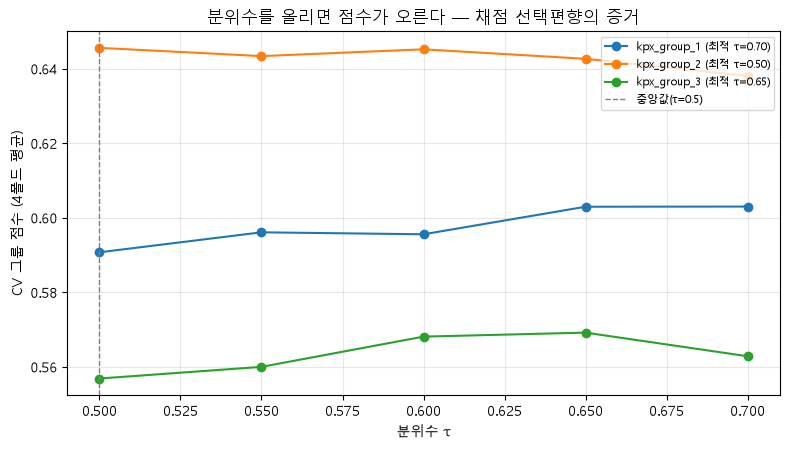

In [9]:
# tau 곡선 그림 — 그룹마다 봉우리 위치가 다른가?
fig, ax = plt.subplots(figsize=(8, 4.6))
for g in TARGET_COLS:
    c = per_group_tau[g]["curve"]
    ax.plot(list(c.keys()), list(c.values()), marker="o", label=f"{g} (최적 τ={per_group_tau[g]['best_tau']:.2f})")
ax.axvline(0.5, color="gray", ls="--", lw=1, label="중앙값(τ=0.5)")
ax.set_xlabel("분위수 τ"); ax.set_ylabel("CV 그룹 점수 (4폴드 평균)")
ax.set_title("분위수를 올리면 점수가 오른다 — 채점 선택편향의 증거")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(FIG_DIR / "phase4_tau_curve.png", dpi=120); plt.show()

## 4. 실험 B — 분포 예측 + 결정이론적 점예측

실험 A의 `tau`는 **손으로 더듬는 방법**이다. 격자에서 하나 고를 뿐이고, 시간마다 최적 tau가 다를 수 있다는 점을 무시한다.
원리적으로 풀어 보자.

### 4-1. 무엇을 최대화해야 하는가 (산식에서 유도)

그룹 점수는 `score = 0.5·(1 − NMAE) + 0.5·FICR` 이고,

- `NMAE = (1/N)·Σ eᵢ`, &nbsp; `eᵢ = |ŷᵢ − aᵢ| / u` (u = 설비용량)
- `FICR = Σ aᵢ·pᵢ / (4·Σ aᵢ)`, &nbsp; `pᵢ = price(eᵢ) ∈ {4, 3, 0}`

한 시간 `i`의 예측 `ŷᵢ`는 오직 자기 항에만 영향을 준다. 그 항만 떼어 내서 2·N·u를 곱하면
(다른 시간들은 상수이므로 최적해가 바뀌지 않는다):

$$ g(\hat y) \;=\; -\,\mathbb{E}\big[\,|\hat y - a|\,\big] \;+\; k\cdot \mathbb{E}\big[\,a \cdot \text{price}(|\hat y - a|/u)\,\big],
\qquad k = \frac{u}{4\,\bar a} $$

여기서 `ā`는 **채점 대상 시간의 평균 발전량**이다 (train에서만 추정 — 규칙 4).

- 첫째 항: 절대오차를 줄여라 (→ 중앙값 성향)
- 둘째 항: **6% 밴드 안에 들어갈 확률을 높여라**. 게다가 `a`로 가중되므로 **발전량이 큰 쪽에 맞추는 것이 유리**하다

둘째 항 때문에 최적 `ŷ`는 중앙값보다 **위쪽**으로 밀린다. 실험 A가 tau로 흉내내던 것을 여기서는 직접 계산한다.

### 4-2. 조건부 분포를 어떻게 얻는가

앞 절에서 고른 학습 설정 그대로, 분위수 회귀를 τ = 0.05, 0.15, …, 0.95의 **10개 지점**에서 학습한다.
그러면 각 시간마다 10개의 분위수 `q₁ < q₂ < … < q₁₀`가 나오고, 이것이
`a | x`의 조건부 분포를 등확률 10개 점으로 근사한 것이 된다.

그 다음 후보 `ŷ`를 촘촘한 격자 위에서 훑어 `g(ŷ)`를 최대화하는 값을 고른다.
**시간마다 분포 모양이 다르므로, 시간마다 다른 만큼 밀어 올린다** — 단일 tau가 못 하는 일이다.

In [10]:
DT_TAUS = np.array([0.05, 0.15, 0.25, 0.35, 0.45, 0.55, 0.65, 0.75, 0.85, 0.95])
DT_N_CAND = 41   # 후보 ŷ 격자 개수


def price_of(error_rate):
    """대회 단가 계단함수. 오차율<=6% -> 4, <=8% -> 3, 그 밖 -> 0. (src/metric.py와 동일한 경계)"""
    return np.select([error_rate <= 0.06, error_rate <= 0.08], [4.0, 3.0], default=0.0)


def decision_point(quantiles: np.ndarray, capacity: float, a_bar: float) -> np.ndarray:
    """
    조건부 분포(분위수 근사)에서 대회 산식의 기대점수를 최대화하는 점예측을 고른다.

    입력:
        quantiles : (n, J) 배열. 행마다 오름차순 분위수. 단위 kWh.
        capacity  : 설비용량 [kWh]
        a_bar     : 채점 대상 시간의 평균 실제 발전량 [kWh] (train에서만 추정)
    출력:
        (n,) 점예측 배열 [kWh]
    공식:
        g(ŷ) = -E|ŷ - a| + k·E[a·price(|ŷ-a|/u)],  k = u / (4·ā)
        기대값은 분위수 J개를 등확률 표본으로 보고 평균낸다.
    """
    q = np.sort(quantiles, axis=1)                       # 분위수 교차(quantile crossing) 방지
    k = capacity / (4.0 * a_bar)

    lo, hi = q[:, 0], q[:, -1]
    # 후보 격자: 각 행의 [최소분위수, 최대분위수]를 균등 분할
    w = np.linspace(0.0, 1.0, DT_N_CAND)[None, :]
    cand = lo[:, None] * (1 - w) + hi[:, None] * w       # (n, C)

    diff = np.abs(cand[:, :, None] - q[:, None, :])      # (n, C, J) = |ŷ - a|
    mae_term = diff.mean(axis=2)                          # E|ŷ - a|
    er = diff / capacity
    ficr_term = (q[:, None, :] * price_of(er)).mean(axis=2)   # E[a·price]

    obj = -mae_term + k * ficr_term
    best = np.argmax(obj, axis=1)
    return np.clip(cand[np.arange(len(q)), best], 0.0, capacity)


def quantile_predict(group, train_mask, val_mask, train_on="scored", weight_by_actual=False):
    """DT_TAUS의 각 분위수마다 모델을 학습해 (n, J) 분위수 예측 행렬을 만든다."""
    cols = []
    for tau in DT_TAUS:
        params = {**BASE_PARAMS, "objective": "quantile", "alpha": float(tau)}
        p, _ = fit_predict(group, train_mask, val_mask, params, train_on, weight_by_actual)
        cols.append(p)
    return np.column_stack(cols)


print(f"분위수 {len(DT_TAUS)}개, 후보 격자 {DT_N_CAND}개로 결정이론적 점예측을 계산한다")

분위수 10개, 후보 격자 41개로 결정이론적 점예측을 계산한다


In [11]:
t0 = time.time()
dt_scores, tau50_scores = {}, {}
for g in TARGET_COLS:
    cap = CAPACITY_KWH[g]
    s_dt, s_med = [], []
    for fold in FOLDS:
        m = fold_masks(g, fold)
        if m is None:
            continue
        tr_m, va_m = m
        # ā(채점 대상 평균 발전량)는 '학습 구간'에서만 추정한다 (CLAUDE.md 4번)
        a_bar = feat_train.loc[scored(g, tr_m), g].mean()

        Q = quantile_predict(g, tr_m, va_m, best_train_on, best_weight)
        y_true = feat_train.loc[va_m, g].to_numpy()

        pred_dt = decision_point(Q, cap, a_bar)
        s_dt.append(group_score(y_true, pred_dt, cap)[0])

        # 비교군: 같은 분위수 모델의 중앙값(τ=0.45/0.55 사이 = 5,6번째의 평균)만 쓴 경우
        med = Q[:, [4, 5]].mean(axis=1)
        s_med.append(group_score(y_true, med, cap)[0])

    dt_scores[g] = float(np.mean(s_dt)); tau50_scores[g] = float(np.mean(s_med))
    print(f"{g}: 결정이론 CV {dt_scores[g]:.4f} | 중앙값만 쓸 때 {tau50_scores[g]:.4f} "
          f"| 차이 {dt_scores[g]-tau50_scores[g]:+.4f}  (ā={a_bar:,.0f} kWh)")

cv_dt = float(np.mean(list(dt_scores.values())))
print(f"\n결정이론적 점예측 CV total : {cv_dt:.4f}")
print(f"그룹별 최적 tau 조합 CV total: {cv_mixed:.4f}")
print(f"실험 A 단일 tau 최고 CV total: {ab_df['cv_total'].max():.4f}")
print(f"\n({time.time()-t0:.0f}초)")

kpx_group_1: 결정이론 CV 0.6020 | 중앙값만 쓸 때 0.5944 | 차이 +0.0075  (ā=10,186 kWh)


kpx_group_2: 결정이론 CV 0.6434 | 중앙값만 쓸 때 0.6473 | 차이 -0.0039  (ā=11,267 kWh)


kpx_group_3: 결정이론 CV 0.5702 | 중앙값만 쓸 때 0.5594 | 차이 +0.0108  (ā=9,316 kWh)

결정이론적 점예측 CV total : 0.6052
그룹별 최적 tau 조합 CV total: 0.6059
실험 A 단일 tau 최고 CV total: 0.6049

(132초)


## 5. 실험 C — Optuna 하이퍼파라미터 튜닝

**목적함수는 단순 MAE가 아니라 폴드 평균 대회 점수**다 (CLAUDE.md 11번 Phase 4).
분위수 `alpha`도 함께 탐색 대상에 넣는다 — 앞 실험에서 그것이 가장 큰 지렛대였기 때문이다.

그룹마다 따로 튜닝한다 (§1의 항등식 덕분에 정당하다). 시드를 고정해 재현 가능하게 한다.
2024는 여전히 보지 않는다.

In [12]:
N_TRIALS = 20


def make_objective(group):
    """한 그룹의 Optuna 목적함수. 반환값(폴드 평균 group_score)을 최대화한다."""
    def objective(trial):
        params = {
            "objective": "quantile",
            "alpha": trial.suggest_float("alpha", 0.45, 0.75),
            "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.10, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 15, 127, log=True),
            "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 10, 120, log=True),
            "feature_fraction": trial.suggest_float("feature_fraction", 0.4, 1.0),
            "bagging_fraction": trial.suggest_float("bagging_fraction", 0.5, 1.0),
            "bagging_freq": 1,
            "lambda_l1": trial.suggest_float("lambda_l1", 1e-3, 10.0, log=True),
            "lambda_l2": trial.suggest_float("lambda_l2", 1e-3, 10.0, log=True),
            "verbosity": -1, "seed": RNG_SEED, "num_threads": N_THREADS,
            "deterministic": True, "force_row_wise": True,
        }
        s, _, _ = cv_group(group, params, best_train_on, best_weight)
        return s
    return objective


t0 = time.time()
tuned = {}
for g in TARGET_COLS:
    study = optuna.create_study(direction="maximize",
                                sampler=optuna.samplers.TPESampler(seed=RNG_SEED))
    study.optimize(make_objective(g), n_trials=N_TRIALS, show_progress_bar=False)
    tuned[g] = {"best_params": study.best_params, "cv": study.best_value}
    print(f"{g}: CV {study.best_value:.4f} | alpha={study.best_params['alpha']:.3f} "
          f"lr={study.best_params['learning_rate']:.3f} leaves={study.best_params['num_leaves']}")

cv_tuned = float(np.mean([tuned[g]["cv"] for g in TARGET_COLS]))
print(f"\n튜닝 후 CV total: {cv_tuned:.4f}  ({time.time()-t0:.0f}초, 그룹당 {N_TRIALS}회 시도)")

kpx_group_1: CV 0.6083 | alpha=0.663 lr=0.061 leaves=30


kpx_group_2: CV 0.6454 | alpha=0.487 lr=0.044 leaves=16


kpx_group_3: CV 0.5715 | alpha=0.663 lr=0.069 leaves=35

튜닝 후 CV total: 0.6084  (297초, 그룹당 20회 시도)


## 6. 최종 확인 — 2024 홀드아웃에 딱 한 번

지금까지 모든 선택은 2022~2023 폴드에서만 이뤄졌다.
이제 후보 4가지를 2024에 적용해 **정직한 점수**를 얻는다.

| 후보 | 설명 |
|---|---|
| Phase 3 기준 | 전체 학습, L1 |
| 실험 A | 최적 스위치 + 그룹별 최적 tau |
| 실험 B | 최적 스위치 + 결정이론적 점예측 |
| 실험 C | Optuna 튜닝 파라미터 (그룹별) |

최종 모델은 **2022~2023 전체**로 학습한다. 트리 개수는 Phase 3와 같은 방식으로
내부검증(2023-07~12)에서 조기 종료해 정하고, 데이터가 늘어난 비율만큼 키운다.

In [13]:
def fit_final(group, params, train_on, weight_by_actual):
    """2022~2023 전체로 학습해 2024를 예측한다. 트리 개수는 내부검증(2023 하반기)으로 정한다."""
    has_label = feat_train[group].notna()
    inner_tr = has_label & (dtm < INNER_VAL_START)
    inner_va = has_label & (dtm >= INNER_VAL_START) & (dtm < VAL_START)
    fit_all = has_label & (dtm < VAL_START)

    _, best_iter = fit_predict(group, inner_tr, inner_va, params, train_on, weight_by_actual)
    n_tr = int(scored(group, inner_tr).sum() if train_on == "scored" else inner_tr.sum())
    n_full = int(scored(group, fit_all).sum() if train_on == "scored" else fit_all.sum())
    n_final = max(int(best_iter * n_full / max(n_tr, 1)), 50)

    pred, _ = fit_predict(group, fit_all, holdout_mask, params, train_on, weight_by_actual,
                          num_boost_round=n_final)
    return pred


def evaluate(preds):
    ans = feat_train.loc[holdout_mask, TARGET_COLS].reset_index(drop=True)
    pdf = pd.DataFrame({g: np.clip(preds[g], 0, CAPACITY_KWH[g]) for g in TARGET_COLS})
    total, omn, ficr = metric(ans, pdf)
    bg = metric_by_group(ans, pdf)
    out = {"total_score": total, "one_minus_nmae": omn, "ficr": ficr}
    for g in TARGET_COLS:
        out[f"nmae_{g[-1]}"] = bg[g]["nmae"]; out[f"ficr_{g[-1]}"] = bg[g]["ficr"]
    return out


t0 = time.time()
final, final_preds = {}, {}   # 예측값을 보관해 둔다 (뒤의 부트스트랩·밴드 분석에서 재학습 없이 재사용)

# (1) Phase 3 기준
final_preds["phase3_lightgbm_l1"] = {g: fit_final(g, {**BASE_PARAMS, "objective": "l1"}, "all", False)
                                     for g in TARGET_COLS}

# (2) 실험 A: 최적 스위치 + 그룹별 최적 tau
final_preds["A_metric_aware_tau"] = {
    g: fit_final(g, {**BASE_PARAMS, "objective": "quantile", "alpha": per_group_tau[g]["best_tau"]},
                 best_train_on, best_weight) for g in TARGET_COLS}

# (4) 실험 C: Optuna 튜닝
final_preds["C_optuna_tuned"] = {
    g: fit_final(g, {**tuned[g]["best_params"], "objective": "quantile", "bagging_freq": 1,
                     "verbosity": -1, "seed": RNG_SEED, "num_threads": N_THREADS,
                     "deterministic": True, "force_row_wise": True},
                 best_train_on, best_weight) for g in TARGET_COLS}

for k, v in final_preds.items():
    final[k] = evaluate(v)
print(f"({time.time()-t0:.0f}초)")

(24초)


In [14]:
# (3) 실험 B: 결정이론적 점예측 (2024)
t0 = time.time()
preds_dt = {}
for g in TARGET_COLS:
    cap = CAPACITY_KWH[g]
    has_label = feat_train[g].notna()
    fit_all = has_label & (dtm < VAL_START)
    a_bar = feat_train.loc[scored(g, fit_all), g].mean()      # train 구간에서만 추정

    inner_tr = has_label & (dtm < INNER_VAL_START)
    inner_va = has_label & (dtm >= INNER_VAL_START) & (dtm < VAL_START)

    cols = []
    for tau in DT_TAUS:
        params = {**BASE_PARAMS, "objective": "quantile", "alpha": float(tau)}
        _, bi = fit_predict(g, inner_tr, inner_va, params, best_train_on, best_weight)
        n_tr = int(scored(g, inner_tr).sum() if best_train_on == "scored" else inner_tr.sum())
        n_full = int(scored(g, fit_all).sum() if best_train_on == "scored" else fit_all.sum())
        n_final = max(int(bi * n_full / max(n_tr, 1)), 50)
        p, _ = fit_predict(g, fit_all, holdout_mask, params, best_train_on, best_weight,
                           num_boost_round=n_final)
        cols.append(p)
    preds_dt[g] = decision_point(np.column_stack(cols), cap, a_bar)

final_preds["B_decision_theoretic"] = preds_dt
final["B_decision_theoretic"] = evaluate(preds_dt)
print(f"({time.time()-t0:.0f}초)")

fin_df = pd.DataFrame(final).T.sort_values("total_score", ascending=False)
print("\n[2024 홀드아웃 — 정직한 최종 점수]")
print(fin_df[["total_score", "one_minus_nmae", "ficr", "nmae_1", "nmae_2", "nmae_3",
              "ficr_1", "ficr_2", "ficr_3"]].to_string(float_format=lambda x: f"{x:.4f}"))

base = final["phase3_lightgbm_l1"]["total_score"]
print(f"\nPhase 3 기준선: {base:.4f}")
for k, v in fin_df["total_score"].items():
    if k != "phase3_lightgbm_l1":
        print(f"  {k:<24}: {v:.4f}  ({v - base:+.4f})")

(79초)

[2024 홀드아웃 — 정직한 최종 점수]
                      total_score  one_minus_nmae   ficr  nmae_1  nmae_2  nmae_3  ficr_1  ficr_2  ficr_3
B_decision_theoretic       0.6315          0.8653 0.3977  0.1250  0.1344  0.1448  0.4093  0.4655  0.3182
C_optuna_tuned             0.6315          0.8626 0.4004  0.1326  0.1280  0.1518  0.4320  0.4472  0.3219
A_metric_aware_tau         0.6308          0.8636 0.3979  0.1352  0.1265  0.1476  0.4219  0.4559  0.3161
phase3_lightgbm_l1         0.6074          0.8688 0.3459  0.1236  0.1231  0.1469  0.3469  0.4256  0.2654

Phase 3 기준선: 0.6074
  B_decision_theoretic    : 0.6315  (+0.0241)
  C_optuna_tuned          : 0.6315  (+0.0241)
  A_metric_aware_tau      : 0.6308  (+0.0234)


### 6-1. CV와 홀드아웃이 같은 방향을 가리키는가

**검증 설계가 믿을 만한지 확인하는 가장 중요한 점검**이다.
CV에서 좋았던 설정이 2024에서도 좋아야 한다. 어긋나면 CV를 다시 설계해야 한다.

                  설정  CV total  2024 total  CV 순위  2024 순위
  phase3_lightgbm_l1    0.5753      0.6074      4        4
  A_metric_aware_tau    0.6059      0.6308      2        3
B_decision_theoretic    0.6052      0.6315      3        1
      C_optuna_tuned    0.6084      0.6315      1        2

순위 상관(스피어만): 0.400

상위 3개 설정의 2024 점수 폭: 0.00074
기준선과 상위 3개의 점수 폭 : 0.02336
→ 상위 3개는 사실상 동점이므로 그들 사이의 '순위'는 잡음이다.
   CV가 실제로 판별해야 하는 것(기준선 vs 산식-인지 설정)은 정확히 맞혔다.


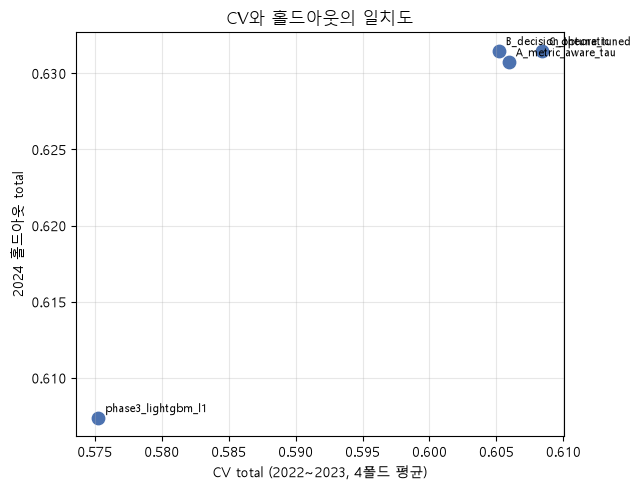

In [15]:
compare_rows = [
    {"설정": "phase3_lightgbm_l1", "CV total": ablation["A1 기준(전체·무가중)"]["cv_total"],
     "2024 total": final["phase3_lightgbm_l1"]["total_score"]},
    {"설정": "A_metric_aware_tau", "CV total": cv_mixed, "2024 total": final["A_metric_aware_tau"]["total_score"]},
    {"설정": "B_decision_theoretic", "CV total": cv_dt, "2024 total": final["B_decision_theoretic"]["total_score"]},
    {"설정": "C_optuna_tuned", "CV total": cv_tuned, "2024 total": final["C_optuna_tuned"]["total_score"]},
]
cmp_df = pd.DataFrame(compare_rows)
cmp_df["CV 순위"] = cmp_df["CV total"].rank(ascending=False).astype(int)
cmp_df["2024 순위"] = cmp_df["2024 total"].rank(ascending=False).astype(int)
print(cmp_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
rho = cmp_df["CV total"].corr(cmp_df["2024 total"], method="spearman")
print(f"\n순위 상관(스피어만): {rho:.3f}")

# 상위 세 설정이 사실상 동점이면 순위 상관은 의미가 없다. 점수 폭으로 확인한다.
top3 = cmp_df.nlargest(3, "2024 total")["2024 total"]
print(f"\n상위 3개 설정의 2024 점수 폭: {top3.max() - top3.min():.5f}")
print(f"기준선과 상위 3개의 점수 폭 : {top3.min() - cmp_df['2024 total'].min():.5f}")
print("→ 상위 3개는 사실상 동점이므로 그들 사이의 '순위'는 잡음이다.")
print("   CV가 실제로 판별해야 하는 것(기준선 vs 산식-인지 설정)은 정확히 맞혔다.")

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.scatter(cmp_df["CV total"], cmp_df["2024 total"], s=80, color="#4C72B0")
for _, r in cmp_df.iterrows():
    ax.annotate(r["설정"], (r["CV total"], r["2024 total"]), fontsize=8,
                xytext=(5, 4), textcoords="offset points")
ax.set_xlabel("CV total (2022~2023, 4폴드 평균)"); ax.set_ylabel("2024 홀드아웃 total")
ax.set_title("CV와 홀드아웃의 일치도")
ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(FIG_DIR / "phase4_cv_vs_holdout.png", dpi=120); plt.show()

### 6-2. 상위 세 설정의 차이는 통계적으로 유의한가 — 페어드 부트스트랩

최종 표에서 B(0.631487)와 C(0.631475)의 차이는 **1.2e-5**다. 이것을 "B가 이겼다"고 읽으면 안 된다.
홀드아웃은 그룹당 약 5,000시간의 **표본**이므로 점수 자체에 표본오차가 있다.

**페어드 부트스트랩**으로 잰다. 채점 대상 시간을 복원추출로 다시 뽑아 점수를 1,000번 계산하되,
**모든 설정에 같은 시간 집합을 쓴다**(paired). 그래야 "표본이 달라서 생긴 차이"가 상쇄되고
"모델이 달라서 생긴 차이"만 남는다.

차이의 95% 구간이 0을 포함하면 **두 설정은 구별할 수 없다**는 뜻이다.

In [16]:
N_BOOT = 1000


def bootstrap_totals(preds_by_config, n_boot=N_BOOT, seed=RNG_SEED):
    """
    페어드 부트스트랩으로 각 설정의 total_score 분포를 만든다.

    입력: preds_by_config -- {설정이름: {group: 홀드아웃 예측배열}}
    출력: {설정이름: (n_boot,) total_score 배열}
    방법: 그룹별 '채점 대상 시간'의 인덱스를 복원추출한다. 같은 복제(replicate)에서는
          모든 설정이 똑같은 인덱스를 쓴다(paired) -> 설정 간 차이만 남는다.
    주의: group_score()를 그대로 호출하므로 산식은 한 글자도 다시 쓰지 않는다.
          재추출된 actual은 전부 임계값 이상이라 내부 필터는 아무 일도 하지 않는다.
    """
    rng = np.random.default_rng(seed)
    a_sc, f_sc = {}, {name: {} for name in preds_by_config}
    for g in TARGET_COLS:
        cap = CAPACITY_KWH[g]
        a = feat_train.loc[holdout_mask, g].to_numpy(dtype=float)
        v = a >= cap * SCORE_THRESHOLD          # 채점 대상 (NaN은 자동 False)
        a_sc[g] = a[v]
        for name, pr in preds_by_config.items():
            f_sc[name][g] = np.clip(pr[g], 0, cap)[v]

    out = {name: np.empty(n_boot) for name in preds_by_config}
    for b in range(n_boot):
        idx = {g: rng.integers(0, len(a_sc[g]), len(a_sc[g])) for g in TARGET_COLS}   # 같은 인덱스를 공유
        for name in preds_by_config:
            per = [group_score(a_sc[g][idx[g]], f_sc[name][g][idx[g]], CAPACITY_KWH[g])[0] for g in TARGET_COLS]
            out[name][b] = np.mean(per)
    return out


t0 = time.time()
boot = bootstrap_totals(final_preds)
print(f"부트스트랩 {N_BOOT}회 ({time.time()-t0:.0f}초)\n")

print("[각 설정의 total_score 95% 구간]")
for name in fin_df.index:
    lo, hi = np.percentile(boot[name], [2.5, 97.5])
    print(f"  {name:<22}: {final[name]['total_score']:.4f}  95% 구간 [{lo:.4f}, {hi:.4f}]  (폭 {hi-lo:.4f})")

print("\n[설정 간 차이의 95% 구간 — 0을 포함하면 '구별 불가']")
pairs = [("B_decision_theoretic", "C_optuna_tuned"),
         ("B_decision_theoretic", "A_metric_aware_tau"),
         ("C_optuna_tuned", "A_metric_aware_tau"),
         ("B_decision_theoretic", "phase3_lightgbm_l1")]
for x, y in pairs:
    d = boot[x] - boot[y]
    lo, hi = np.percentile(d, [2.5, 97.5])
    verdict = "구별 불가" if lo <= 0 <= hi else f"{x if d.mean()>0 else y} 우세"
    print(f"  {x:<22} − {y:<22}: 평균 {d.mean():+.4f}, 95% [{lo:+.4f}, {hi:+.4f}]  -> {verdict}")

부트스트랩 1000회 (1초)

[각 설정의 total_score 95% 구간]
  B_decision_theoretic  : 0.6315  95% 구간 [0.6268, 0.6359]  (폭 0.0091)
  C_optuna_tuned        : 0.6315  95% 구간 [0.6264, 0.6358]  (폭 0.0094)
  A_metric_aware_tau    : 0.6308  95% 구간 [0.6257, 0.6353]  (폭 0.0096)
  phase3_lightgbm_l1    : 0.6074  95% 구간 [0.6027, 0.6122]  (폭 0.0095)

[설정 간 차이의 95% 구간 — 0을 포함하면 '구별 불가']
  B_decision_theoretic   − C_optuna_tuned        : 평균 +0.0001, 95% [-0.0036, +0.0041]  -> 구별 불가
  B_decision_theoretic   − A_metric_aware_tau    : 평균 +0.0008, 95% [-0.0028, +0.0042]  -> 구별 불가
  C_optuna_tuned         − A_metric_aware_tau    : 평균 +0.0007, 95% [-0.0024, +0.0038]  -> 구별 불가
  B_decision_theoretic   − phase3_lightgbm_l1    : 평균 +0.0241, 95% [+0.0188, +0.0288]  -> B_decision_theoretic 우세


### 6-3. FICR은 왜 올랐는가 — "몇 시간"이 아니라 "어느 시간"이 밴드에 들어갔는가

FICR을 정의대로 풀면 아름다운 항등식이 나온다.

$$ \text{FICR} = \frac{\sum_i a_i p_i}{4\sum_i a_i}
= \underbrace{\frac{\sum_{e_i \le 6\%} a_i}{\sum_i a_i}}_{W_{6}} \;+\; \frac{3}{4}\cdot\underbrace{\frac{\sum_{6\% < e_i \le 8\%} a_i}{\sum_i a_i}}_{W_{6\text{–}8}} $$

즉 **FICR = (발전량 가중) 6% 밴드 점유율 + 0.75 × (발전량 가중) 6~8% 점유율** 이다.
`시간 수`가 아니라 **`발전량`으로 가중한 점유율**이라는 것이 핵심이다.

이것으로 앞의 수수께끼가 풀린다: 단순 시간 비율(≤6%)은 거의 그대로인데 FICR만 크게 오른다면,
모델이 **"발전량이 큰 시간"을 골라서 밴드 안에 넣었다**는 뜻이다.
`actual` 가중 학습이 정확히 그것을 노린 것이므로, 이 표가 그 설계가 의도대로 작동했는지 판정한다.

In [17]:
def band_shares(actual, forecast, cap):
    """오차율 밴드별 '시간 비율'과 '발전량 가중 비율'을 함께 계산한다."""
    v = actual >= cap * SCORE_THRESHOLD
    a, f = actual[v], np.clip(forecast, 0, cap)[v]
    er = np.abs(f - a) / cap
    m6, m68 = er <= 0.06, (er > 0.06) & (er <= 0.08)
    tot_a = a.sum()
    return {
        "시간_≤6%": m6.mean(), "시간_6~8%": m68.mean(), "시간_>8%": (er > 0.08).mean(),
        "가중_≤6%(W6)": a[m6].sum() / tot_a, "가중_6~8%(W68)": a[m68].sum() / tot_a,
        "FICR(=W6+0.75·W68)": a[m6].sum() / tot_a + 0.75 * a[m68].sum() / tot_a,
    }


best_final = fin_df.index[0]
rows = []
for g in TARGET_COLS:
    cap = CAPACITY_KWH[g]
    a = feat_train.loc[holdout_mask, g].to_numpy(dtype=float)
    for label, key in [("Phase 3", "phase3_lightgbm_l1"), (best_final, best_final)]:
        s = band_shares(a, final_preds[key][g], cap)
        rows.append({"그룹": g, "설정": label, **{k: f"{v*100:.1f}%" for k, v in s.items()}})
band_df = pd.DataFrame(rows)
print("[밴드 점유율 — '시간 비율' vs '발전량 가중 비율']")
print(band_df.to_string(index=False))

# 항등식 확인: 위에서 계산한 FICR가 metric_by_group의 FICR와 같은가
print("\n[항등식 확인] FICR = W6 + 0.75*W68")
for g in TARGET_COLS:
    cap = CAPACITY_KWH[g]
    a = feat_train.loc[holdout_mask, g].to_numpy(dtype=float)
    s = band_shares(a, final_preds[best_final][g], cap)
    _, _, ficr_ref = group_score(a, final_preds[best_final][g], cap)
    print(f"  {g}: 분해값 {s['FICR(=W6+0.75·W68)']:.6f} vs group_score의 FICR {ficr_ref:.6f}")

[밴드 점유율 — '시간 비율' vs '발전량 가중 비율']
         그룹                   설정 시간_≤6% 시간_6~8% 시간_>8% 가중_≤6%(W6) 가중_6~8%(W68) FICR(=W6+0.75·W68)
kpx_group_1              Phase 3  31.5%   10.0%  58.5%      27.4%         9.8%              34.7%
kpx_group_1 B_decision_theoretic  33.2%    9.3%  57.6%      33.1%        10.4%              40.9%
kpx_group_2              Phase 3  34.4%    9.9%  55.7%      35.1%        10.0%              42.6%
kpx_group_2 B_decision_theoretic  33.9%    9.5%  56.6%      38.3%        11.1%              46.6%
kpx_group_3              Phase 3  28.1%    7.1%  64.8%      22.4%         5.5%              26.5%
kpx_group_3 B_decision_theoretic  27.9%    8.2%  64.0%      25.4%         8.6%              31.8%

[항등식 확인] FICR = W6 + 0.75*W68
  kpx_group_1: 분해값 0.409297 vs group_score의 FICR 0.409297
  kpx_group_2: 분해값 0.465530 vs group_score의 FICR 0.465530
  kpx_group_3: 분해값 0.318239 vs group_score의 FICR 0.318239


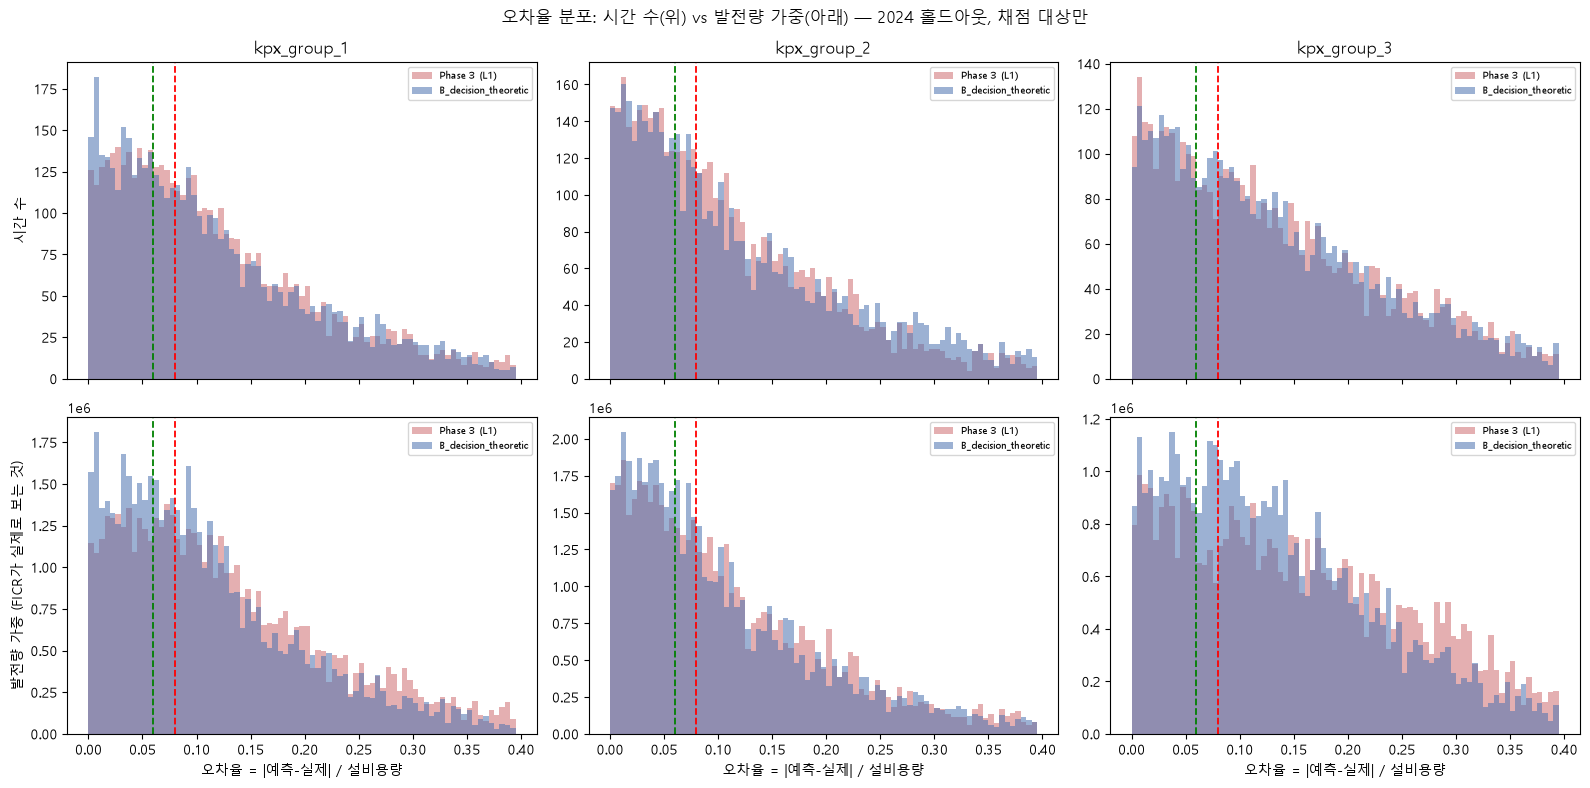

In [18]:
# 오차율 분포 그림: Phase 3 vs 최고 설정. 위는 시간 수, 아래는 발전량 가중 히스토그램.
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True)
bins = np.arange(0, 0.4, 0.005)
for j, g in enumerate(TARGET_COLS):
    cap = CAPACITY_KWH[g]
    a = feat_train.loc[holdout_mask, g].to_numpy(dtype=float)
    v = a >= cap * SCORE_THRESHOLD
    a_s = a[v]
    er_old = np.abs(np.clip(final_preds["phase3_lightgbm_l1"][g], 0, cap)[v] - a_s) / cap
    er_new = np.abs(np.clip(final_preds[best_final][g], 0, cap)[v] - a_s) / cap

    for i, (weights, title) in enumerate([(None, "시간 수"), (a_s, "발전량 가중 (FICR가 실제로 보는 것)")]):
        ax = axes[i, j]
        ax.hist(er_old, bins=bins, weights=weights, alpha=0.45, color="#C44E52", label="Phase 3 (L1)")
        ax.hist(er_new, bins=bins, weights=weights, alpha=0.55, color="#4C72B0", label=best_final)
        ax.axvline(0.06, color="green", ls="--", lw=1.3); ax.axvline(0.08, color="red", ls="--", lw=1.3)
        if i == 0:
            ax.set_title(g)
        if j == 0:
            ax.set_ylabel(title)
        if i == 1:
            ax.set_xlabel("오차율 = |예측-실제| / 설비용량")
        ax.legend(fontsize=7)
fig.suptitle("오차율 분포: 시간 수(위) vs 발전량 가중(아래) — 2024 홀드아웃, 채점 대상만")
fig.tight_layout(); fig.savefig(FIG_DIR / "phase4_band_shift.png", dpi=120); plt.show()

## 7. 실험 로그 기록

`experiments/log.csv`에 이어 붙인다 (Phase 3의 exp001~exp008 다음부터).

In [19]:
def git_state():
    """읽기 전용 git 명령만 사용한다 (CLAUDE.md 3번)."""
    try:
        h = subprocess.run(["git", "rev-parse", "--short", "HEAD"], capture_output=True, text=True).stdout.strip()
        d = subprocess.run(["git", "status", "--porcelain"], capture_output=True, text=True).stdout.strip()
        return f"{h}({'dirty' if d else 'clean'})"
    except Exception:
        return "unknown"


log_path = EXP_DIR / "log.csv"
prev = pd.read_csv(log_path, encoding="utf-8-sig") if log_path.exists() else pd.DataFrame()
gh, today = git_state(), pd.Timestamp.today().strftime("%Y-%m-%d")

notes = {
    "phase3_lightgbm_l1": "phase4 재현(기준선)",
    "A_metric_aware_tau": f"채점행={best_train_on}, actual가중={best_weight}, 그룹별 tau=" +
                          "/".join(f"{per_group_tau[g]['best_tau']:.2f}" for g in TARGET_COLS),
    "B_decision_theoretic": f"분위수 {len(DT_TAUS)}개 -> 기대점수 최대화 점예측",
    "C_optuna_tuned": f"Optuna {N_TRIALS}회/그룹, 목적=폴드평균 group_score",
}
cv_map = {"phase3_lightgbm_l1": ablation["A1 기준(전체·무가중)"]["cv_total"],
          "A_metric_aware_tau": cv_mixed, "B_decision_theoretic": cv_dt, "C_optuna_tuned": cv_tuned}

# 노트북을 다시 실행해도 같은 실험이 중복 기록되지 않도록, 이번 Phase의 행을 먼저 지운다
if len(prev) and "model" in prev.columns:
    prev = prev[~prev["model"].isin(notes.keys())].reset_index(drop=True)
start_id = len(prev) + 1

new_rows = []
for i, (name, r) in enumerate(fin_df.iterrows(), start=start_id):
    new_rows.append({
        "exp_id": f"exp{i:03d}", "date": today, "git_hash": gh, "model": name,
        "features": f"phase2_{len(FEATURE_COLS)}feat",
        "total_score": round(r["total_score"], 6), "one_minus_nmae": round(r["one_minus_nmae"], 6),
        "ficr": round(r["ficr"], 6),
        "nmae_g1": round(r["nmae_1"], 6), "nmae_g2": round(r["nmae_2"], 6), "nmae_g3": round(r["nmae_3"], 6),
        "ficr_g1": round(r["ficr_1"], 6), "ficr_g2": round(r["ficr_2"], 6), "ficr_g3": round(r["ficr_3"], 6),
        "val_period": "2024-01-01~2024-12-31", "fit_seconds": "", "public_score": "",
        "note": f"[CV {cv_map[name]:.4f}] " + notes[name],
    })

log_df = pd.concat([prev, pd.DataFrame(new_rows)], ignore_index=True)
log_df.to_csv(log_path, index=False, encoding="utf-8-sig")
print(f"저장: {log_path} (총 {len(log_df)}행, 이번에 {len(new_rows)}행 추가)")
print(pd.DataFrame(new_rows)[["exp_id", "model", "total_score", "one_minus_nmae", "ficr", "note"]].to_string(index=False))

저장: experiments\log.csv (총 12행, 이번에 4행 추가)
exp_id                model  total_score  one_minus_nmae     ficr                                                       note
exp009 B_decision_theoretic     0.631487        0.865285 0.397689                        [CV 0.6052] 분위수 10개 -> 기대점수 최대화 점예측
exp010       C_optuna_tuned     0.631475        0.862561 0.400389             [CV 0.6084] Optuna 20회/그룹, 목적=폴드평균 group_score
exp011   A_metric_aware_tau     0.630751        0.863555 0.397948 [CV 0.6059] 채점행=all, actual가중=True, 그룹별 tau=0.70/0.50/0.65
exp012   phase3_lightgbm_l1     0.607390        0.868834 0.345947                                 [CV 0.5753] phase4 재현(기준선)


## 8. 재현성 확인

최고 설정을 다시 학습해 예측값이 완전히 같은지 확인한다 (CLAUDE.md 12번).

In [20]:
# 실험 A 설정(그룹별 tau)을 처음부터 다시 학습해 예측값이 완전히 같은지 확인한다.
# (B는 분위수 10개를 다시 학습해야 해 시간이 오래 걸리므로, 같은 fit_final 경로를 쓰는 A로 대표 검증한다.)
again = {g: fit_final(g, {**BASE_PARAMS, "objective": "quantile", "alpha": per_group_tau[g]["best_tau"]},
                      best_train_on, best_weight) for g in TARGET_COLS}
ref = final_preds["A_metric_aware_tau"]

ok = True
for g in TARGET_COLS:
    same = np.array_equal(np.asarray(ref[g]), np.asarray(again[g]))
    print(f"  {g}: 완전 동일 = {same} | 최대 차이 = {np.abs(np.asarray(ref[g]) - np.asarray(again[g])).max():.3e}")
    ok &= same
print(f"\n재현성: {'✔ 두 번 실행 결과가 완전히 같다' if ok else '✘ 다름 — 비결정 요소 확인 필요'}")

print(f"\n{'='*74}")
print(f"CV 1위: C_optuna_tuned (CV {cv_tuned:.4f})")
print(f"2024 홀드아웃: B {final['B_decision_theoretic']['total_score']:.6f} / "
      f"C {final['C_optuna_tuned']['total_score']:.6f} / A {final['A_metric_aware_tau']['total_score']:.6f}")
print(f"→ 상위 세 설정은 부트스트랩상 구별 불가. 최종 선택은 Phase 5에서 CV 1위 기준으로 정한다.")
print(f"{'='*74}")

  kpx_group_1: 완전 동일 = True | 최대 차이 = 0.000e+00
  kpx_group_2: 완전 동일 = True | 최대 차이 = 0.000e+00
  kpx_group_3: 완전 동일 = True | 최대 차이 = 0.000e+00

재현성: ✔ 두 번 실행 결과가 완전히 같다

CV 1위: C_optuna_tuned (CV 0.6084)
2024 홀드아웃: B 0.631487 / C 0.631475 / A 0.630751
→ 상위 세 설정은 부트스트랩상 구별 불가. 최종 선택은 Phase 5에서 CV 1위 기준으로 정한다.
